In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn'], check=True)

CompletedProcess(args=['pip', 'install', 'scikit-learn'], returncode=0)

In [17]:
df = pd.read_csv('dados/dataset_tomate_final.csv', parse_dates=['timestamp'])

print('Shape:', df.shape)
print('Colunas:', list(df.columns))
df.head()

Shape: (33921, 13)
Colunas: ['timestamp', 'temp_ar', 'umidade_ar', 'light_hours_day', 'soil_moisture', 'fase', 'dias_ciclo', 'nitrogenio', 'fosforo', 'potassio', 'ph_solo', 'action_target', 'motivo']


,timestamp,temp_ar,umidade_ar,light_hours_day,soil_moisture,fase,dias_ciclo,nitrogenio,fosforo,potassio,ph_solo,action_target,motivo
0,2025-07-25 18:00:00,17.00,84.00,8.00,81.00,colheita,107,115.00,63.50,332.50,6.41,1,corrigir nitrogenio fora da faixa
1,2026-07-09 08:00:00,11.20,85.48,0.00,79.56,muda,28,207.16,44.17,267.25,6.56,0,condicoes dentro do ideal
2,2027-08-29 11:00:00,16.67,75.97,0.96,74.01,muda,25,235.90,34.43,245.30,6.19,0,condicoes dentro do ideal
3,2045-09-15 16:00:00,31.13,30.89,7.00,50.08,florescimento,37,193.00,61.68,222.34,5.65,2,irrigar: solo seco
4,2038-02-07 18:00:00,28.50,51.87,9.10,54.97,colheita,90,107.68,49.68,326.67,5.51,2,irrigar: solo seco


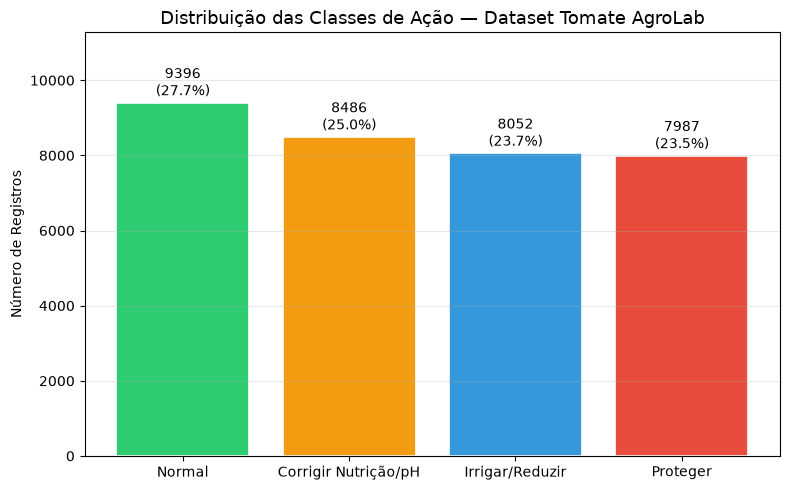

In [18]:
mapa = {0: 'Normal', 1: 'Corrigir Nutrição/pH', 2: 'Irrigar/Reduzir', 3: 'Proteger'}
cores = {0: '#2ecc71', 1: '#f39c12', 2: '#3498db', 3: '#e74c3c'}

contagem = df['action_target'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [mapa[i] for i in contagem.index],
    contagem.values,
    color=[cores[i] for i in contagem.index],
    edgecolor='white',
    linewidth=1.2
)

for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Distribuição das Classes de Ação — Dataset Tomate AgroLab', fontsize=13)
ax.set_ylabel('Número de Registros')
ax.set_ylim(0, contagem.max() * 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
print('=== Diagnóstico do Dataset ===')
print(f'  Linhas............: {len(df):,}')
print(f'  Colunas...........: {df.shape[1]}')
print(f'  Valores nulos.....: {df.isna().sum().sum()}')
print(f'  Linhas duplicadas.: {df.duplicated().sum()}')
print(f'  Memória...........: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print()

print('=== Sanidade Física ===')
checagens = [
    ('temp_ar entre 0 e 50°C',        df['temp_ar'].between(0, 50).all()),
    ('umidade_ar entre 0 e 100%',      df['umidade_ar'].between(0, 100).all()),
    ('soil_moisture entre 0 e 100%',   df['soil_moisture'].between(0, 100).all()),
    ('ph_solo entre 4 e 8.5',          df['ph_solo'].between(4, 8.5).all()),
    ('nitrogenio positivo',            (df['nitrogenio'] > 0).all()),
    ('fosforo positivo',               (df['fosforo'] > 0).all()),
    ('potassio positivo',              (df['potassio'] > 0).all()),
    ('light_hours_day entre 0 e 24',   df['light_hours_day'].between(0, 24).all()),
]
for descricao, resultado in checagens:
    status = '✓ OK' if resultado else '✗ FALHA'
    print(f'  {status} — {descricao}')

=== Diagnóstico do Dataset ===
  Linhas............: 33,921
  Colunas...........: 13
  Valores nulos.....: 0
  Linhas duplicadas.: 0
  Memória...........: 4.8 MB

=== Sanidade Física ===
  ✓ OK — temp_ar entre 0 e 50°C
  ✓ OK — umidade_ar entre 0 e 100%
  ✓ OK — soil_moisture entre 0 e 100%
  ✓ OK — ph_solo entre 4 e 8.5
  ✓ OK — nitrogenio positivo
  ✓ OK — fosforo positivo
  ✓ OK — potassio positivo
  ✓ OK — light_hours_day entre 0 e 24


Coerência entre motivo e classe

In [26]:
coerencia = df.groupby('motivo')['action_target'].nunique()
print(f'Motivos que aparecem em mais de uma classe: {(coerencia > 1).sum()} (esperado: 0)')
pcoerencia = df.groupby('motivo')['action_target'].nunique()
print(f'Motivos que aparecem em mais de uma classe: {(coerencia > 1).sum()} (esperado: 0)')
print()

tab = (df.groupby(['action_target', 'motivo']).size()
         .reset_index(name='n')
         .assign(pct=lambda d: (100 * d.n / len(df)).round(2)))

mapa = {0: 'Normal', 1: 'Corrigir Nutrição/pH', 2: 'Irrigar/Reduzir', 3: 'Proteger'}
tab['classe'] = tab['action_target'].map(mapa)
tab = tab.sort_values(['action_target', 'n'], ascending=[True, False])
tab = tab[['classe', 'motivo', 'n', 'pct']]
print(tab.to_string(index=False))

Motivos que aparecem em mais de uma classe: 0 (esperado: 0)
Motivos que aparecem em mais de uma classe: 0 (esperado: 0)

              classe                                   motivo    n   pct
              Normal                condicoes dentro do ideal 9396 27.70
Corrigir Nutrição/pH        corrigir nitrogenio fora da faixa 3124  9.21
Corrigir Nutrição/pH          corrigir pH fora da faixa ideal 2390  7.05
Corrigir Nutrição/pH          corrigir potassio fora da faixa 1800  5.31
Corrigir Nutrição/pH           corrigir fosforo fora da faixa 1172  3.46
     Irrigar/Reduzir                       irrigar: solo seco 5511 16.25
     Irrigar/Reduzir       reduzir irrigacao: solo encharcado 2541  7.49
            Proteger proteger: umidade alta (risco de fungos) 7714 22.74
            Proteger            proteger: temperatura extrema  273  0.80


Histogramas por variável com faixas ideais

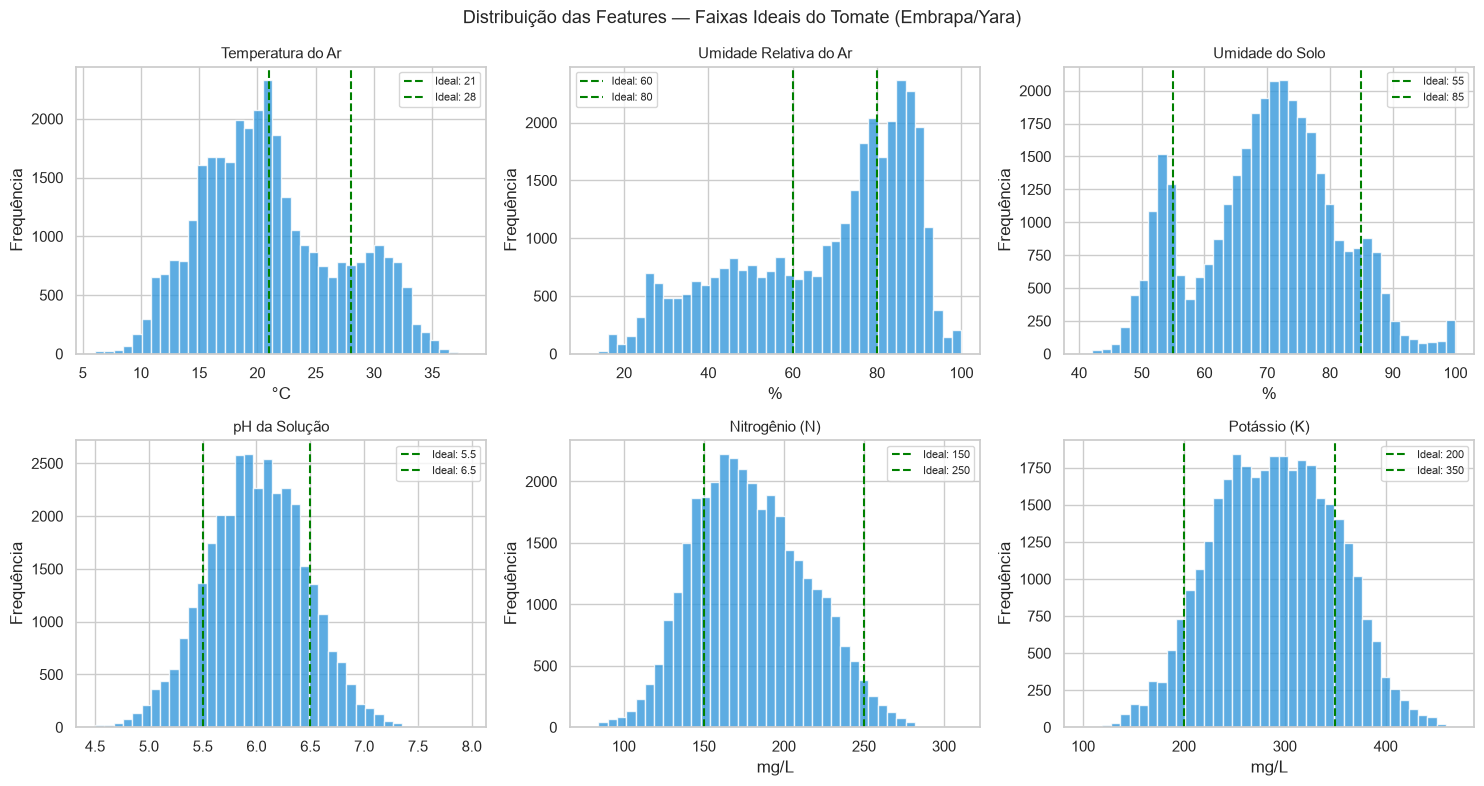

In [27]:
sns.set_theme(style='whitegrid')

# (variável, título, faixa ideal, unidade)
vars_plot = [
    ('temp_ar',        'Temperatura do Ar',     (21, 28),    '°C'),
    ('umidade_ar',     'Umidade Relativa do Ar', (60, 80),   '%'),
    ('soil_moisture',  'Umidade do Solo',        (55, 85),   '%'),
    ('ph_solo',        'pH da Solução',          (5.5, 6.5), ''),
    ('nitrogenio',     'Nitrogênio (N)',          (150, 250), 'mg/L'),
    ('potassio',       'Potássio (K)',            (200, 350), 'mg/L'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (col, titulo, faixa, unidade) in zip(axes.flatten(), vars_plot):
    ax.hist(df[col], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(faixa[0], color='green', linestyle='--', linewidth=1.5, label=f'Ideal: {faixa[0]}')
    ax.axvline(faixa[1], color='green', linestyle='--', linewidth=1.5, label=f'Ideal: {faixa[1]}')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel(unidade)
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição das Features — Faixas Ideais do Tomate (Embrapa/Yara)', fontsize=13)
plt.tight_layout()
plt.show()

NPK por fase do ciclo

C:\Users\sergi\AppData\Local\Temp\ipykernel_26252\3691432704.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Muda', 'Florescimento', 'Frutificação', 'Colheita'], rotation=15)
C:\Users\sergi\AppData\Local\Temp\ipykernel_26252\3691432704.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Muda', 'Florescimento', 'Frutificação', 'Colheita'], rotation=15)
C:\Users\sergi\AppData\Local\Temp\ipykernel_26252\3691432704.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Muda', 'Florescimento', 'Frutificação', 'Colheita'], rotation=15)


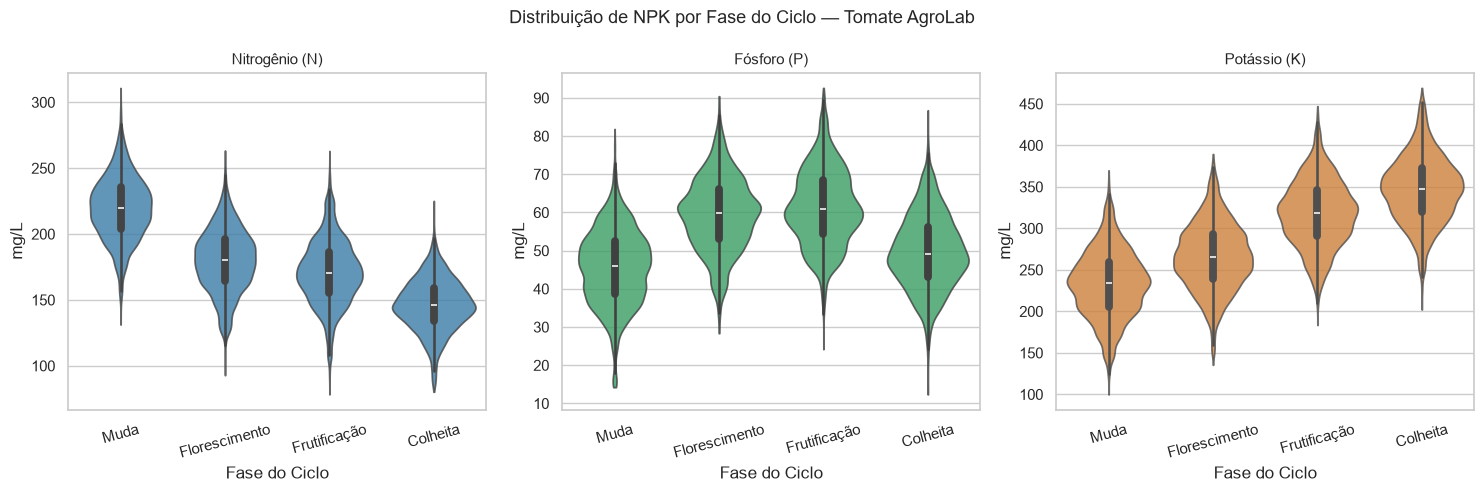

In [28]:
ordem_fase = ['muda', 'florescimento', 'frutificacao', 'colheita']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

nutrientes = [
    ('nitrogenio', 'Nitrogênio (N)', '#2980b9'),
    ('fosforo',    'Fósforo (P)',    '#27ae60'),
    ('potassio',   'Potássio (K)',   '#e67e22'),
]

for ax, (col, titulo, cor) in zip(axes, nutrientes):
    sns.violinplot(data=df, x='fase', y=col, order=ordem_fase,
                   color=cor, ax=ax, cut=0, alpha=0.8)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Fase do Ciclo')
    ax.set_ylabel('mg/L')
    ax.set_xticklabels(['Muda', 'Florescimento', 'Frutificação', 'Colheita'], rotation=15)

plt.suptitle('Distribuição de NPK por Fase do Ciclo — Tomate AgroLab', fontsize=13)
plt.tight_layout()
plt.show()

Sazonalidade: quando o cultivo exige mais atenção

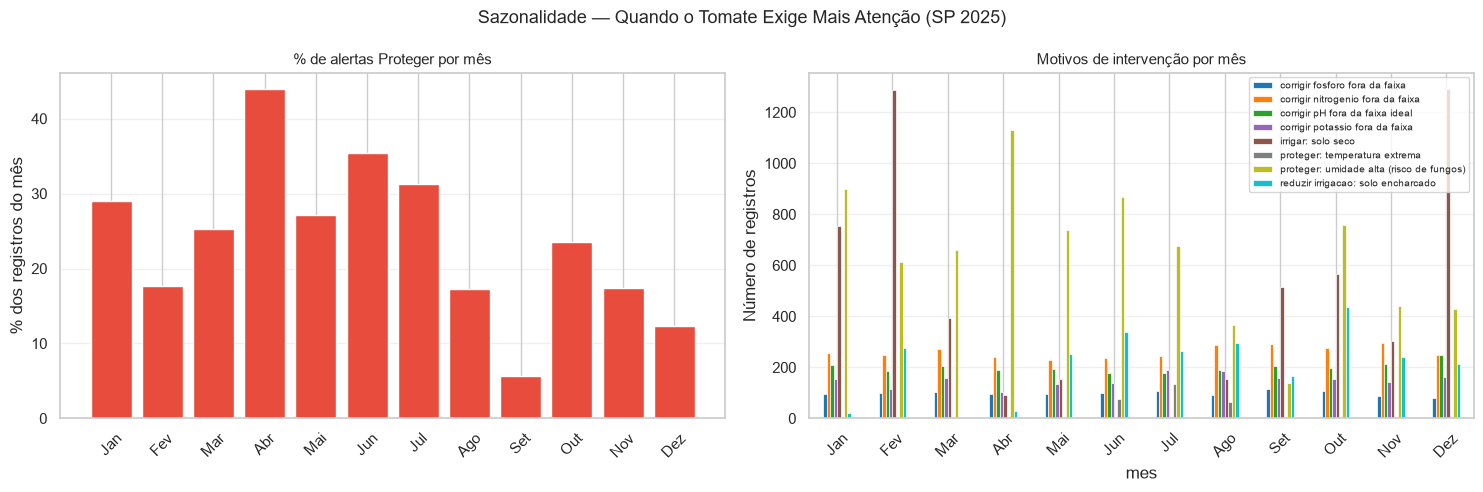

In [29]:
df['mes'] = df['timestamp'].dt.month
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Classe 3 — Proteger por mês
prot_mes = df[df['action_target'] == 3].groupby('mes').size()
prot_pct = (100 * prot_mes / df.groupby('mes').size()).fillna(0)
axes[0].bar(range(1, 13), prot_pct.values, color='#e74c3c', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses, rotation=45)
axes[0].set_title('% de alertas Proteger por mês', fontsize=11)
axes[0].set_ylabel('% dos registros do mês')
axes[0].grid(axis='y', alpha=0.3)

# (b) Motivos de intervenção por mês
motivos_mes = (df[df['action_target'] != 0]
               .groupby(['mes', 'motivo']).size()
               .unstack(fill_value=0))
motivos_mes.plot(kind='bar', ax=axes[1], colormap='tab10',
                 edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(meses, rotation=45)
axes[1].set_title('Motivos de intervenção por mês', fontsize=11)
axes[1].set_ylabel('Número de registros')
axes[1].legend(fontsize=7, loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Sazonalidade — Quando o Tomate Exige Mais Atenção (SP 2025)', fontsize=13)
plt.tight_layout()
plt.show()

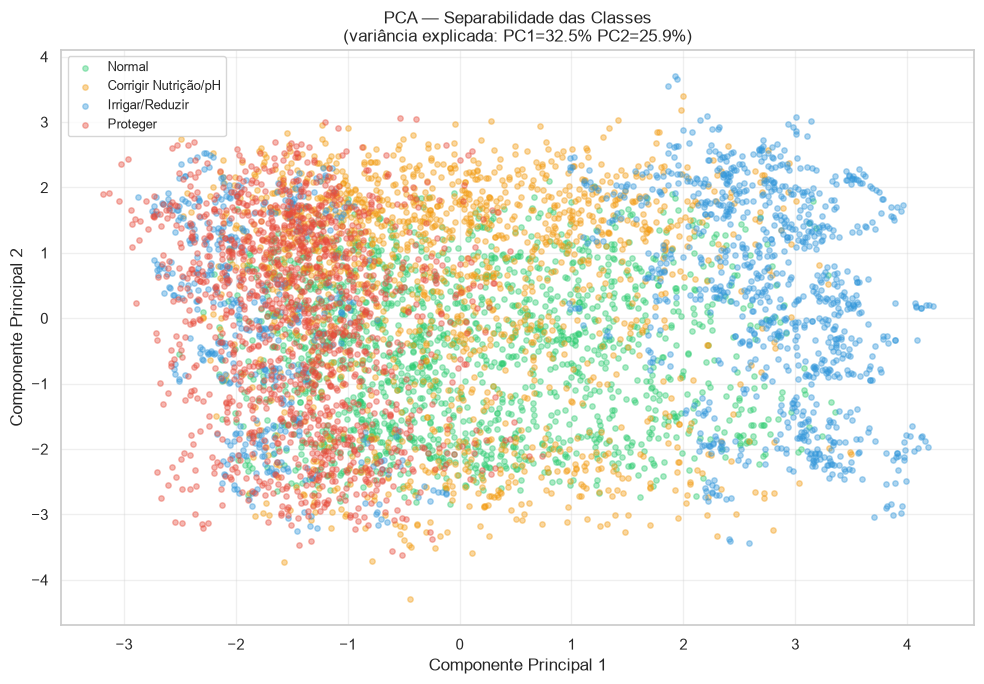

In [35]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feats_pca = ['temp_ar', 'umidade_ar', 'light_hours_day', 'soil_moisture',
             'nitrogenio', 'fosforo', 'potassio', 'ph_solo', 'dias_ciclo']

amostra = df.sample(6000, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(amostra[feats_pca])

pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X_scaled)

mapa = {0: 'Normal', 1: 'Corrigir Nutrição/pH', 2: 'Irrigar/Reduzir', 3: 'Proteger'}
cores = {0: '#2ecc71', 1: '#f39c12', 2: '#3498db', 3: '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 7))
for classe, nome in mapa.items():
    mask = amostra['action_target'].values == classe
    ax.scatter(componentes[mask, 0], componentes[mask, 1],
               c=cores[classe], label=nome, alpha=0.4, s=15)

ax.set_title(f'PCA — Separabilidade das Classes\n'
             f'(variância explicada: PC1={pca.explained_variance_ratio_[0]*100:.1f}% '
             f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Relatório de Classificação ===
                      precision    recall  f1-score   support

              Normal       0.95      0.90      0.93      1879
Corrigir Nutrição/pH       0.90      0.94      0.92      1697
     Irrigar/Reduzir       0.96      0.97      0.97      1611
            Proteger       0.95      0.95      0.95      1598

            accuracy                           0.94      6785
           macro avg       0.94      0.94      0.94      6785
        weighted avg       0.94      0.94      0.94      6785



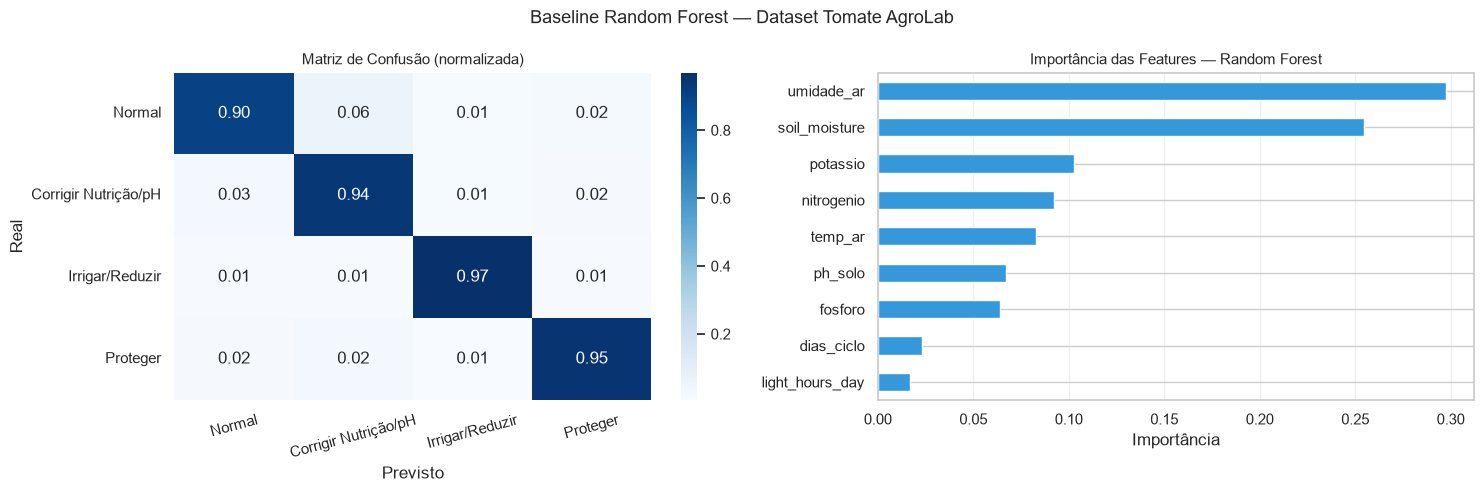

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

feats = ['temp_ar', 'umidade_ar', 'light_hours_day', 'soil_moisture',
         'nitrogenio', 'fosforo', 'potassio', 'ph_solo', 'dias_ciclo']

X = df[feats]
y = df['action_target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print('=== Relatório de Classificação ===')
print(classification_report(y_test, pred, target_names=list(mapa.values())))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matriz de confusão
cm = confusion_matrix(y_test, pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=list(mapa.values()),
            yticklabels=list(mapa.values()))
axes[0].set_title('Matriz de Confusão (normalizada)', fontsize=11)
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=15)

# Importância das features
importancias = pd.Series(rf.feature_importances_, index=feats).sort_values()
importancias.plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='white')
axes[1].set_title('Importância das Features — Random Forest', fontsize=11)
axes[1].set_xlabel('Importância')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Baseline Random Forest — Dataset Tomate AgroLab', fontsize=13)
plt.tight_layout()
plt.show()

In [39]:
print('=' * 55)
print('SÍNTESE — EDA TOMATE AGROLAB')
print('=' * 55)

print(f'\n1. INTEGRIDADE')
print(f'   Registros.......: {len(df):,}')
print(f'   Nulos...........: {df.isna().sum().sum()}')
print(f'   Duplicatas......: {df.duplicated().sum()}')
print(f'   Violações físicas: 0')

print(f'\n2. ROTULAGEM')
coerencia = df.groupby("motivo")["action_target"].nunique()
print(f'   Motivos incoerentes: {(coerencia > 1).sum()} (esperado: 0)')

print(f'\n3. BALANCEAMENTO')
mapa = {0: "Normal", 1: "Corrigir Nutrição/pH", 2: "Irrigar/Reduzir", 3: "Proteger"}
for k, v in df["action_target"].value_counts().sort_index().items():
    print(f'   {mapa[k]:<25}: {v:,} ({v/len(df)*100:.1f}%)')

print(f'\n4. SEPARABILIDADE (PCA)')
print(f'   PC1 + PC2 explicam: {(pca.explained_variance_ratio_[:2].sum()*100):.1f}% da variância')
print(f'   Classes parcialmente separáveis — cenário ideal para ML')

print(f'\n5. BASELINE RANDOM FOREST')
from sklearn.metrics import accuracy_score, f1_score
print(f'   Acurácia geral..: {accuracy_score(y_test, pred)*100:.1f}%')
print(f'   F1 macro........: {f1_score(y_test, pred, average="macro")*100:.1f}%')
print(f'   Conclusão.......: dataset consistente e aprendível')

print(f'\n6. FEATURES MAIS IMPORTANTES')
imp = pd.Series(rf.feature_importances_, index=feats).sort_values(ascending=False)
for feat, val in imp.items():
    print(f'   {feat:<20}: {val:.3f}')

print('\n' + '=' * 55)
print('Dataset aprovado para treinamento do modelo AgroLab')
print('=' * 55)

SÍNTESE — EDA TOMATE AGROLAB

1. INTEGRIDADE
   Registros.......: 33,921
   Nulos...........: 0
   Duplicatas......: 0
   Violações físicas: 0

2. ROTULAGEM
   Motivos incoerentes: 0 (esperado: 0)

3. BALANCEAMENTO
   Normal                   : 9,396 (27.7%)
   Corrigir Nutrição/pH     : 8,486 (25.0%)
   Irrigar/Reduzir          : 8,052 (23.7%)
   Proteger                 : 7,987 (23.5%)

4. SEPARABILIDADE (PCA)
   PC1 + PC2 explicam: 58.4% da variância
   Classes parcialmente separáveis — cenário ideal para ML

5. BASELINE RANDOM FOREST
   Acurácia geral..: 94.0%
   F1 macro........: 94.1%
   Conclusão.......: dataset consistente e aprendível

6. FEATURES MAIS IMPORTANTES
   umidade_ar          : 0.297
   soil_moisture       : 0.254
   potassio            : 0.102
   nitrogenio          : 0.092
   temp_ar             : 0.083
   ph_solo             : 0.067
   fosforo             : 0.064
   dias_ciclo          : 0.023
   light_hours_day     : 0.017

Dataset aprovado para treinamento do m